In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
nu = np.array([[-1,1,0],
                [-1,1,1],
                [1,-1,-1],
                [0,0,1]])
def aCalc(c, x):
    a1 = c[0]*(x[0]*x[1])*(x[0]>=1 and x[1]>=1)
    a2 = c[1]*(x[2])*(x[2]>=1)
    a3 = c[2]*(x[2])*(x[2]>=1)
    return np.array([a1, a2, a3])

### 3.1.1
Verify that if aj kept constant, then pj are independent and poisson distributed with lambda = aj*tau

![image.png](attachment:image.png)

### 3.1.2

Implementing tau-leaping algorithm and using the same rate constants as in section 2.1 with T=50 and tau=0.2

#### First implementation of explicit tau leaping

In [4]:
def explicit_tau_leaping(c, X0, T, tau):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t),4))

    X[0]=X0

    for i in range(0, len(t)-1):
        a = aCalc(c, X[i])
        #aSum = sum(a)
        
        P = np.random.poisson(lam = (a*tau)) # (3,) array of pj values
        X[i+1] = X[i] + nu @ P
    return t, X

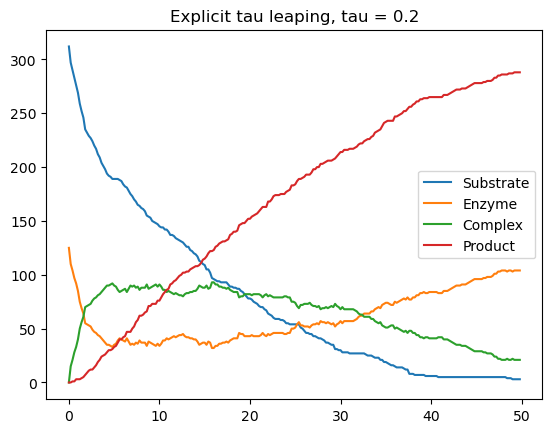

In [5]:
c = [0.0017, 1e-4, 0.1] # rate constants

T = 50 # Total time
tau = 0.2

X0 = [312, 125, 0, 0] # Initial # of each species

t, X = explicit_tau_leaping(c, X0, T, tau)
X = np.transpose(X)
n = len(t)-1
plt.plot(t, X[0], label="Substrate")
plt.plot(t, X[1], label="Enzyme")
plt.plot(t, X[2], label="Complex")
plt.plot(t, X[3], label="Product")
plt.title("Explicit tau leaping, tau = 0.2")
plt.legend()
plt.show()

### 3.1.3
Estimating Zdelt = E[X4(T)], compare with Z obtained in 2.3. Fix a threshold 1 - alpha and iteratively increase N until you achieve the desired tolerance. Compare at that threshold the confidence interval obtained by SSA algorithm with explicit tau leaping.

#### Explicit tau leaping for comparison with section 2

In [6]:
def pilot_run(solver, Nb):
    
    X4 = np.zeros(Nb)

    for i in range(Nb):
        t, X = solver(c, X0, T, tau)
        X4[i] = X[-1,3]

    muN = 1/Nb * sum(X4)
    sigN = np.sqrt(1/(Nb-1) * sum((X4 - muN)**2))
    
    return muN, sigN

def iterative_MC(solver, Nb=200, tol=0.2, Nmax= 2000, alpha=0.05):

    cAlph = stats.norm.ppf(1-alpha/2)
    N = Nb

    muN, sigN = pilot_run(solver, Nb)

    while (sigN * cAlph/np.sqrt(N) > tol and N<Nmax):
    
        N = N+1
        
        t, X = solver(c, X0, T, tau)
        
        muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
        sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)
    
    halfwidth  = sigN * cAlph/np.sqrt(N)

    return muN, halfwidth, N

In [7]:
# Parameters for explicit tau leaping
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
tau = 0.2
X0 = [312, 125, 0, 0] # Initial # of each species

# Parameters for Monte Carlo
alpha = 0.05
tol = 0.2
Nb = 200
Nmax = 2000

muN, halfwidth, N = iterative_MC(explicit_tau_leaping)
print("95% confidence interval for mu: [", muN-halfwidth,' , ',muN+halfwidth,']')
print(f'halfwidth is {halfwidth}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 295.9112874878607  ,  296.31113811573243 ]
halfwidth is 0.19992531393588475
Calculated by N =  1780  iterations


#### Various values of tau and sample sizes

In [8]:
def MC_specificSampleSize(solver, N, alpha=0.05):

    cAlph = stats.norm.ppf(1-alpha/2)
    X4 = np.zeros(N)

    for i in range(N):
        t, X = solver(c, X0, T, tau)
        X4[i] = X[-1,3]

    muN = 1/N * sum(X4)
    sigN = np.sqrt(1/(N-1) * sum((X4 - muN)**2))
    
    halfwidth  = sigN * cAlph/np.sqrt(N)

    return muN, halfwidth

In [21]:
tauTest = np.linspace(0.2, 5, 10)#[0.2, 0.3, 0.5, 0.9, 1.7, 2.5, 3.3, 4, 4.5, 5, 6.5]
Ns = [300, 800, 1500]
alpha = 0.05 
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
X0 = [312, 125, 0, 0] # Initial # of each species

resultsExplicit = np.zeros((len(tauTest), len(Ns), 2)) # lists for each N and tau, storing mu and halfwidth

for i, tau in enumerate(tauTest):
    for j, N in enumerate(Ns):
        resultsExplicit[i, j]=MC_specificSampleSize(explicit_tau_leaping, N)

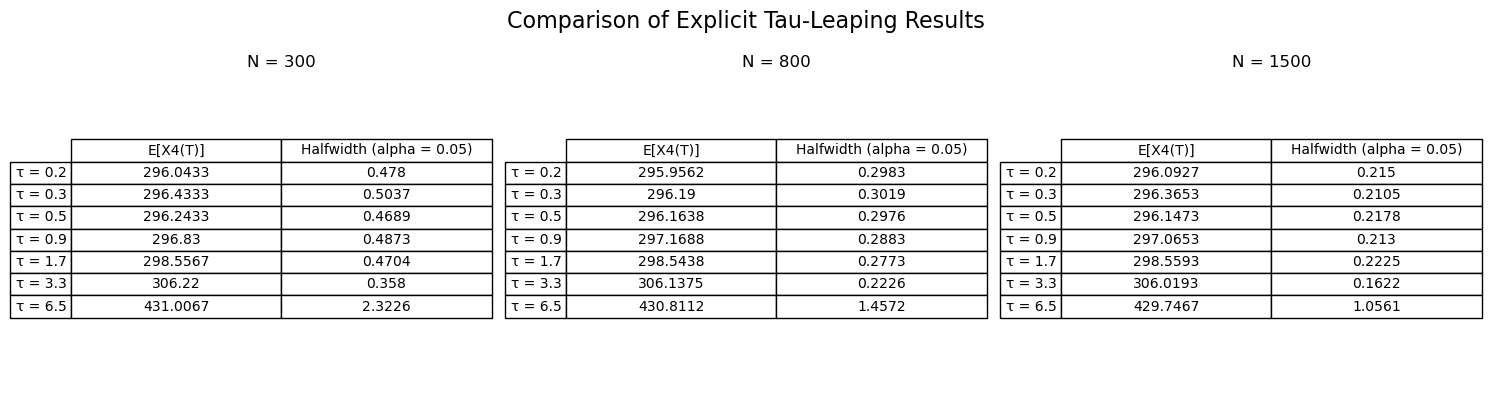

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for j, N in enumerate(Ns):

    ax = axes[j]
    ax.axis("off")

    # table_data shape is (len(tauTest), 2) for this N
    table_data = np.round(resultsExplicit[:, j, :], 4)

    col_labels = ["E[X4(T)]", "Halfwidth (alpha = 0.05)"]
    row_labels = [f"τ = {tau}" for tau in tauTest]

    table = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.3)

    ax.set_title(f"N = {N}", pad=2)

fig.suptitle("Comparison of Explicit Tau-Leaping Results", fontsize=16)

fig.tight_layout()
plt.show()

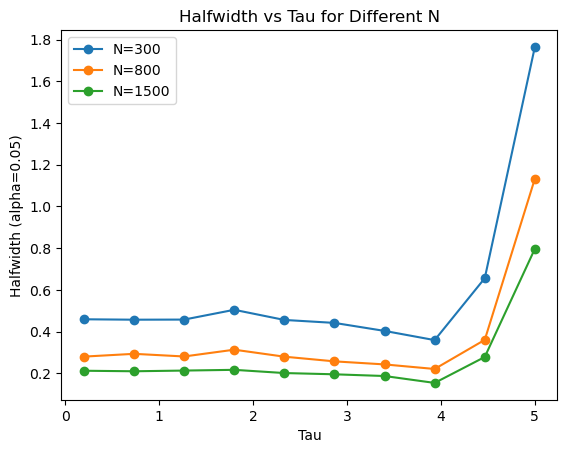

In [22]:
np.shape(resultsExplicit)
resultsExplicit
plt.plot(tauTest, resultsExplicit[:,0,1], marker='o', label='N=300')
plt.plot(tauTest, resultsExplicit[:,1,1], marker='o', label='N=800')
plt.plot(tauTest, resultsExplicit[:,2,1], marker='o', label='N=1500')
plt.xlabel('Tau')
plt.ylabel('Halfwidth (alpha=0.05)')
plt.title('Halfwidth vs Tau for Different N')
plt.legend()
plt.show()  

### 3.1.4

Implicit tau-leaping algorithm

a)

y = X(t) + tau * sum ( aj(y) * nu)
f(y) = y - X(t) - tau * sum ( aj(y) * nu) = 0

y(k+1) = y(k) - inv(jacobi)*f(y(k))

b)

Sampling Pj from poisson(aj(y)*tau)

#### First Implementation implicit tau leaping

In [81]:
def aCont(c, x):
    a1 = c[0]*(x[0]*x[1])
    a2 = c[1]*(x[2])
    a3 = c[2]*(x[2])
    return np.array([a1, a2, a3])

In [82]:
def update_J(J, y, c, tau):
    y0, y1 = y[0], y[1]
    c0, c1, c2 = c

    J[0,0] = 1 + tau*c0*y1
    J[0,1] = tau*c0*y0

    J[1,0] = tau*c0*y1
    J[1,1] = 1 + tau*c0*y0

    J[2,0] = -tau*c0*y1
    J[2,1] = -tau*c0*y0

    J[0,2] = -tau*c1
    J[1,2] = -tau*(c1+c2)
    J[2,2] = 1 + tau*(c1+c2)
    J[3,2] = -tau*c2

    # entries that are constant
    J[0,3] = J[1,3] = J[2,3] = 0
    J[3,0] = J[3,1] = 0
    J[3,3] = 1


In [83]:
def newtons(c, X, tau, tol, Nmax = 100):
    y = X.copy()
    a = aCont(c, y)
    F = y - X - tau*(nu @ a)

    J = np.empty((4,4))   # allocated once
    N = 0
    while np.linalg.norm(F) > tol and N < Nmax:
        update_J(J, y, c, tau)

        delY = np.linalg.solve(J, -F)
        y += delY

        a = aCont(c, y)
        F = y - X - tau*(nu @ a)
        N+=1
    
    return y

In [84]:
def implicit_tau_leaping(c, X0, T, tau, tol=1e-10):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t), 4))
    X[0] = X0

    for i in range(len(t)-1):
        y = newtons(c, X[i], tau, tol)
        a = aCalc(c, y)
        P = np.random.poisson(a * tau)
        X[i+1] = X[i] + nu @ P

    return t, X

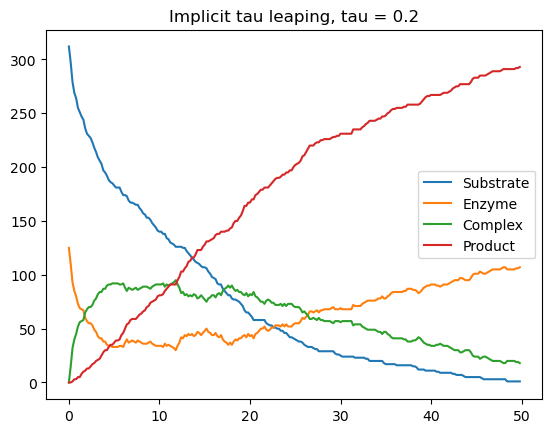

In [95]:
c = [0.0017, 1e-4, 0.1] # rate constants

T = 50 # Total time
tau = 0.2

X0 = [312, 125, 0, 0] # Initial # of each species

t, X = implicit_tau_leaping(c, X0, T, tau)
X = np.transpose(X)
n = len(t)-1
plt.plot(t, X[0], label="Substrate")
plt.plot(t, X[1], label="Enzyme")
plt.plot(t, X[2], label="Complex")
plt.plot(t, X[3], label="Product")
plt.title("Implicit tau leaping, tau = 0.2")
plt.legend()
plt.show()

In [86]:
# Parameters for explicit tau leaping
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
tau = 0.2
X0 = [312, 125, 0, 0] # Initial # of each species

# Parameters for Monte Carlo
alpha = 0.05
tol = 0.2
Nb = 200
Nmax = 2000

muN, halfwidth, N = iterative_MC(explicit_tau_leaping)
print("95% confidence interval for mu: [", muN-halfwidth,' , ',muN+halfwidth,']')
print(f'halfwidth is {halfwidth}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 295.7707592567197  ,  296.1707063577118 ]
halfwidth is 0.1999735504960759
Calculated by N =  1773  iterations


#### Comparison for various vals of tau and sample sizes

In [87]:
tauTest = [0.2, 0.3, 0.5, 0.9, 1.7, 3.3, 6.5]
Ns = [300, 800, 1500]
alpha = 0.05 

results = np.zeros((len(tauTest), len(Ns), 2))

for i, tau in enumerate(tauTest):
    for j, N in enumerate(Ns):
        results[i, j]=MC_specificSampleSize(implicit_tau_leaping, N)

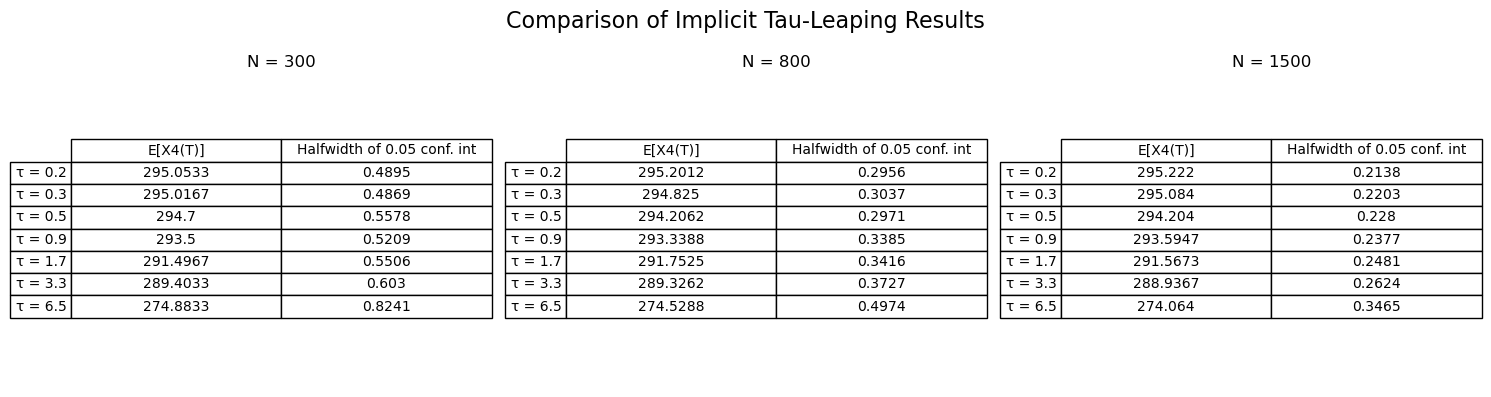

In [96]:
# ---- Plot tables: one table per N ----

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for j, N in enumerate(Ns):

    ax = axes[j]
    ax.axis("off")

    # table_data shape is (len(tauTest), 2) for this N
    table_data = np.round(results[:, j, :], 4)

    col_labels = ["E[X4(T)]", "Halfwidth of 0.05 conf. int"]
    row_labels = [f"τ = {tau}" for tau in tauTest]

    table = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.3)

    ax.set_title(f"N = {N}", pad=2)

fig.suptitle("Comparison of Implicit Tau-Leaping Results", fontsize=16)

fig.tight_layout()
plt.show()